In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Machine_learning\Datasets\car data.csv")
df

,speed,car_age,experience,risk
0,172,22,8.104042,42
1,94,17,11.429461,36
2,186,20,14.819477,45
3,151,10,15.343897,38
4,100,6,16.455807,47
...,...,...,...,...
275,165,10,8.630563,20
276,130,26,6.656316,49
277,142,19,14.610983,20
278,204,7,13.874352,45


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   speed       280 non-null    int64  
 1   car_age     280 non-null    int64  
 2   experience  280 non-null    float64
 3   risk        280 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 8.9 KB


Text(0.5, 1.0, 'Risk vs Car Age')

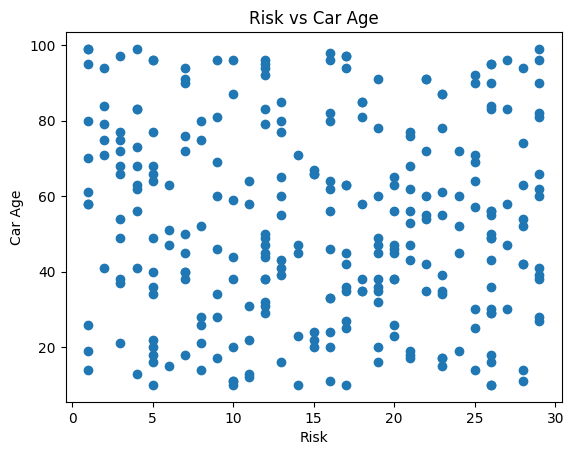

In [4]:
plt.scatter(df["car_age"], df["risk"])
plt.xlabel("Risk")
plt.ylabel("Car Age")
plt.title("Risk vs Car Age")


Text(0.5, 1.0, 'Risk vs Car Speed')

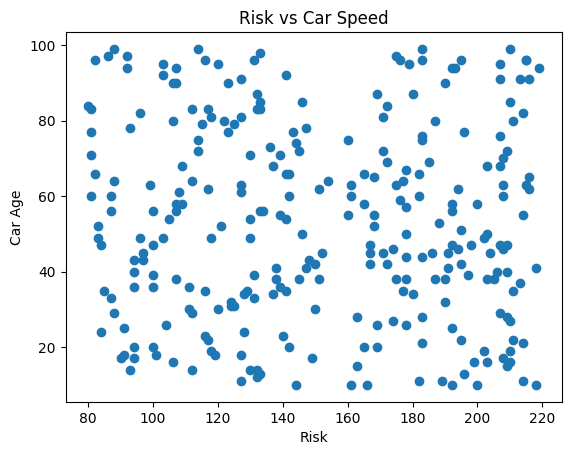

In [5]:
plt.scatter(df["speed"], df["risk"])
plt.xlabel("Risk")
plt.ylabel("Car Age")
plt.title("Risk vs Car Speed")


<Axes: >

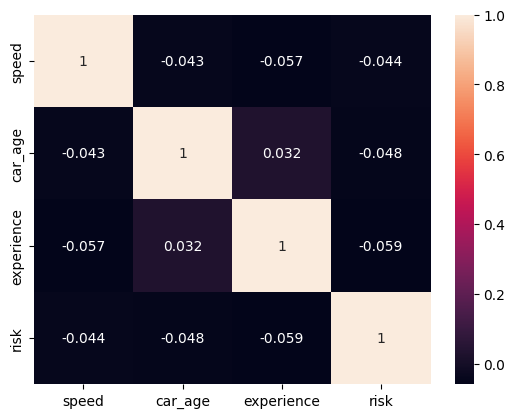

In [6]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only= True), annot= True)

In [7]:
x = df.drop('risk', axis = 1)
y = df['risk']

In [8]:
x.head()

,speed,car_age,experience
0,172,22,8.104042
1,94,17,11.429461
2,186,20,14.819477
3,151,10,15.343897
4,100,6,16.455807


In [9]:
y.head()

0    42
1    36
2    45
3    38
4    47
Name: risk, dtype: int64

In [10]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0.03,-0.14,-0.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['speed','car_age','experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,62.68
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [12]:
model.coef_

array([-0.0302617 , -0.14473869, -0.27965041])

In [13]:
model.intercept_

np.float64(62.68381438116153)

In [14]:
newdata = pd.DataFrame([[30, 46, 50]] , columns=x.columns)
model.predict(newdata)

array([41.1354632])

In [15]:

df['predicted_y'] = model.predict(x)
df.head()

,speed,car_age,experience,risk,predicted_y
0,172,22,8.104042,42,52.028252
1,94,17,11.429461,36,54.182404
2,186,20,14.819477,45,50.016092
3,151,10,15.343897,38,52.375984
4,100,6,16.455807,47,54.187339


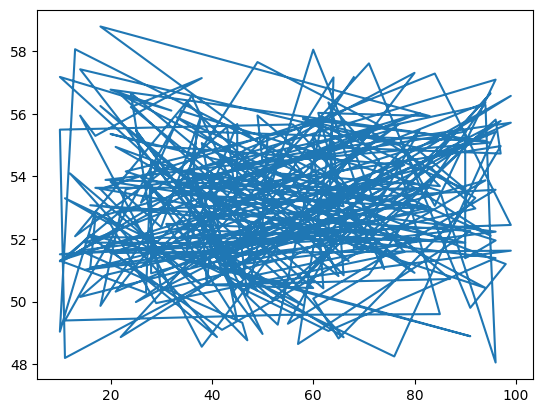

In [16]:
plt.plot(y, df['predicted_y'])

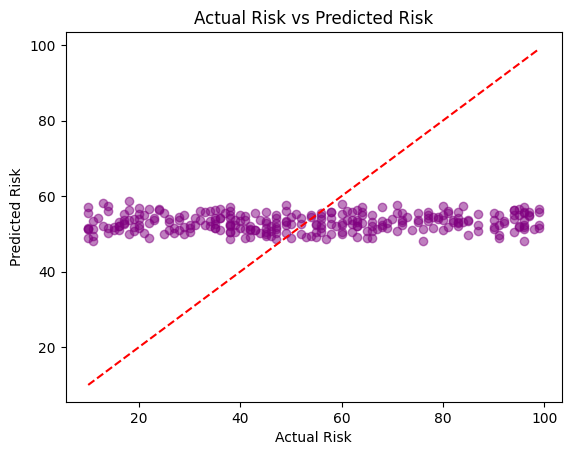

In [17]:
plt.scatter(df['risk'], df['predicted_y'], color='purple', alpha=0.5)

plt.plot([df['risk'].min(), df['risk'].max()], 
         [df['risk'].min(), df['risk'].max()], 
         color='red', linestyle='--')

plt.xlabel('Actual Risk')
plt.ylabel('Predicted Risk')
plt.title('Actual Risk vs Predicted Risk')
plt.show()

In [18]:
df["Loss"] = df["risk"]-df["predicted_y"]
df

,speed,car_age,experience,risk,predicted_y,Loss
0,172,22,8.104042,42,52.028252,-10.028252
1,94,17,11.429461,36,54.182404,-18.182404
2,186,20,14.819477,45,50.016092,-5.016092
3,151,10,15.343897,38,52.375984,-14.375984
4,100,6,16.455807,47,54.187339,-7.187339
...,...,...,...,...,...,...
275,165,10,8.630563,20,53.829707,-33.829707
276,130,26,6.656316,49,53.125146,-4.125146
277,142,19,14.610983,20,51.550651,-31.550651
278,204,7,13.874352,45,51.617288,-6.617288


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mse = mean_squared_error(df['risk'], df['predicted_y'])
mse

654.2206269532247

In [20]:
mae = mean_absolute_error(df['risk'], df['predicted_y'])
mae

21.733253878030197

In [21]:
model.score(x,y)

0.0079924518010972

In [22]:
score =r2_score(y, df['predicted_y'])
score

0.0079924518010972